In [1]:
# Importations

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
from scipy.optimize import curve_fit
from scipy import signal
import glob
from math import sqrt

In [2]:
%matplotlib inline

import matplotlib.pyplot as plt

from matplotlib import rc
import matplotlib.colors as mplcolors
from mpltools import annotation

rc('lines', linewidth=1.5, markeredgecolor='k', markeredgewidth=0.5)
rc('xtick', direction='in', labelsize=9)
rc('ytick', direction='in', labelsize=9)

rc('font', family='serif', size=9)
rc('text', usetex=True)

rc('figure', dpi=200)
rc('savefig', dpi=600)

In [3]:
# Get datas

In [4]:
folderpath1 = '../data/Rattler/20260907_rattler_diffusing_DIC_x100_calib_0p04/'
folderpath2 = '../data/Rattler/20260908_rattler_diffusing_withPEG_DIC/'

files1 = glob.glob(folderpath1 + 'trajectories_*')
# print(files1)
files2 = glob.glob(folderpath2 + 'trajectories_*')

df = pd.read_csv(files1[0])

In [5]:
df.head()

,frame,time,xs,ys,as,sigmas,Is_max,Is,xc,yc,Ac,Ic
0,0,0.000000,0.000006,0.000015,0.000001,1.243597e-07,334.293227,349178.220664,0.000007,0.000015,1.107392e-12,231482.0
1,1,0.010870,0.000006,0.000015,0.000001,1.243597e-07,312.179325,326079.659018,0.000007,0.000015,1.101584e-12,233351.0
2,2,0.021739,0.000006,0.000015,0.000001,1.243597e-07,306.821081,320482.828900,0.000007,0.000015,1.060928e-12,216461.0
3,3,0.032609,0.000006,0.000015,0.000001,1.243597e-07,299.078592,312395.591984,0.000007,0.000015,1.039632e-12,209817.0
4,4,0.043478,0.000006,0.000015,0.000001,1.243597e-07,289.173354,302049.306417,0.000007,0.000015,1.039632e-12,208304.0


In [6]:
columns = ['time', 'xs', 'ys', 'xc', 'yc', 'Is', 'Ac', 'Ic']

In [7]:
# files = copy.deepcopy(files1)
files = files1

nf = len(files)
nt = len(pd.read_csv(files[0])['frame'])

## Method 1

# TS = np.zeros((nt, nf)) * np.nan # time
# XS = np.zeros((nt, nf)) * np.nan # x position, shell
# YS = np.zeros((nt, nf)) * np.nan # y position
# RS = np.zeros((nt, nf)) * np.nan # r position
# XC = np.zeros((nt, nf)) * np.nan # x position, core
# YC = np.zeros((nt, nf)) * np.nan # y position
# RC = np.zeros((nt, nf)) * np.nan # r position
# AC = np.zeros((nt, nf)) * np.nan # area
# IC = np.zeros((nt, nf)) * np.nan # intensity

# for i, file in enumerate(files):
#     datatemp = pd.read_csv(files[i])
#     arraytemp = datatemp.to_numpy()
#     TS[:,i] = datatemp['time']

# del datatemp, arraytemp

## Method 2

# dfs = [pd.read_csv(files[i]) for i in range(nf)]

# TS = np.stack([df['time'].to_numpy() for df in dfs], axis=1) # time
# XS = np.stack([df['xs'].to_numpy() for df in dfs], axis=1) # x position, shell
# YS = np.stack([df['ys'].to_numpy() for df in dfs], axis=1) # y position
# RS = np.sqrt(XS**2 + YS**2) # r position
# XC = np.stack([df['xc'].to_numpy() for df in dfs], axis=1) # x position, core
# YC = np.stack([df['yc'].to_numpy() for df in dfs], axis=1) # y position
# RC = np.sqrt(XC**2 + YC**2) # r position
# AC = np.stack([df['Ac'].to_numpy() for df in dfs], axis=1) # area
# IC = np.stack([df['Ic'].to_numpy() for df in dfs], axis=1) # intensity

# del dfs

## Method 3

dfs = [pd.read_csv(files[i]) for i in range(nf)]

datas = np.stack([df[columns] for df in dfs], axis=2)

In [171]:
def names2datas(files, columns=columns):
    nf = len(files)
    nt = len(pd.read_csv(files[0])['frame'])
    dfs = [pd.read_csv(files[i]) for i in range(nf)]
    datas = np.stack([df[columns] for df in dfs], axis=2)
    return datas, nf, nt

def names2datas_adding_relative(files, columns=columns):
    nf = len(files)
    nt = len(pd.read_csv(files[0])['frame'])
    nc = len(columns) + 1 # + 1 to add the relative distance
    dfs = [pd.read_csv(files[i]) for i in range(nf)]
    datas = np.zeros((nt, nc, nf))
    # for i, df in enumerate(dfs):
    datas[:,:-1,:] = np.stack([df[columns] for df in dfs], axis=2)
    datas[:,-1,:] = np.sqrt((datas[:,3,:] - datas[:,1,:]) ** 2 + (datas[:,4,:] - datas[:,2,:]) ** 2)
    return datas, nf, nt

In [173]:
datas1, nf1, nt1 = names2datas_adding_relative(files1)
datas2, nf2, nt2 = names2datas_adding_relative(files2)

In [10]:
# Plot a few trajectories

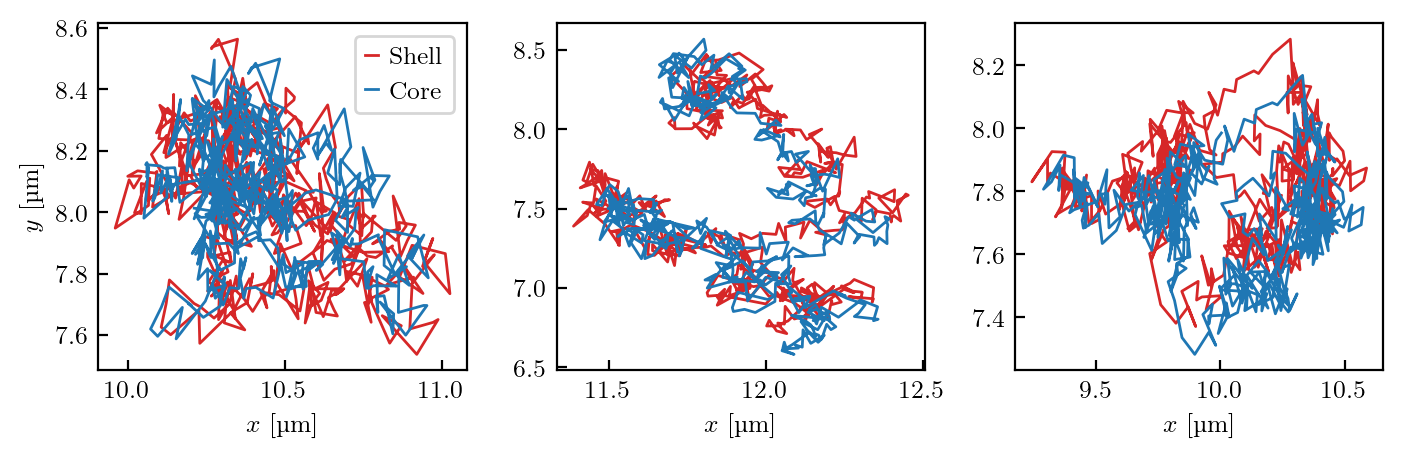

In [12]:
datas = datas2

i1 = 0
i2 = 1
i3 = 4

xs1, ys1, xc1, yc1 = datas[:, 3, i1], datas[:, 4, i1], datas[:, 1, i1], datas[:, 2, i1]
xs2, ys2, xc2, yc2 = datas[:, 3, i2], datas[:, 4, i2], datas[:, 1, i2], datas[:, 2, i2]
xs3, ys3, xc3, yc3 = datas[:, 3, i3], datas[:, 4, i3], datas[:, 1, i3], datas[:, 2, i3]

fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(18/2.54, 6/2.54))

ax1.plot(xs1 * 1e6, ys1 * 1e6, ls='-', c='tab:red', lw=1, label='Shell')
ax1.plot(xc1 * 1e6, yc1 * 1e6, ls='-', c='tab:blue', lw=1, label='Core')

ax2.plot(xs2 * 1e6, ys2 * 1e6, ls='-', c='tab:red', lw=1)
ax2.plot(xc2 * 1e6, yc2 * 1e6, ls='-', c='tab:blue', lw=1)

ax3.plot(xs3 * 1e6, ys3 * 1e6, ls='-', c='tab:red', lw=1)
ax3.plot(xc3 * 1e6, yc3 * 1e6, ls='-', c='tab:blue', lw=1)

ax1.legend(handlelength=0.5, handletextpad=0.5)
ax1.set_ylabel(r'$y$ [\textmu m]')
for ax in [ax1, ax2, ax3]:
    ax.set_xlabel(r'$x$ [\textmu m]')

plt.tight_layout()
plt.show()

In [13]:
def moment(n, x, t, return_std = False, retrieve_mean = False, mean_abs = False):
    """
    Parameters
    ----------
    n: int, moment of order n
    x: array containing the values of interest
    t: an array containing differences of indexes.
    """
    res = np.zeros(len(t))
    std = np.zeros(len(t))
    for i, j in enumerate(t):
        #x_tau = x[j:] - np.mean(x[j:])
        #x_zer = x[0:-j] - np.mean(x[0:-j])
        #res[i] = np.nanmean((x_tau - x_zer)**n)
        Delta_x = x[j:] - x[0:-j]
        if retrieve_mean:
            distribution = (Delta_x - np.mean(Delta_x)) ** n
        else:
            distribution = (Delta_x) ** n
        if mean_abs:
            distribution = np.abs(distribution)
        res[i] = np.nanmean(distribution)
        std[i] = np.nanstd(distribution)
    if return_std:
        return res, std
    else:
        return res

In [14]:
from math import comb

def moment_fft(x: np.ndarray, delta: np.ndarray = np.arange(1, 10, 1), 
               n: int | float = 2, 
               retrieve_mean: bool = False, fake_jumps: bool = False, 
               ):
    """
    FFT-based computation of structure function moments.
    
    For integer n, uses the convolution theorem to compute E[(x[t+d] - x[t])^n]
    efficiently. For non-integer n, falls back to direct computation.
    """

    # Non-integer n: direct method
    if n != int(n):
        return moment(x, delta, n, retrieve_mean, fake_jumps)

    N = len(x)
    res = np.zeros(len(delta), dtype=float)
    n_int = int(n)

    # Precompute FFTs of x^k for k = 0..n  (done ONCE, not per delta)
    size = 2 * N  # zero-pad to avoid circular wrap
    X_ffts = [np.fft.rfft(x ** k, n=size) for k in range(n_int + 1)]

    # Full cross-correlation for each power pair (j, n-j), evaluated at ALL lags at once
    # corr_full[j][d] = sum_t x[t+d]^j * x[t]^(n-j)
    corr_full = [np.fft.irfft(X_ffts[j] * np.conj(X_ffts[n_int - j])) for j in range(n_int + 1)]

    res = np.full(len(delta), np.nan)
    counts = N - np.asarray(delta, dtype=int)  # number of valid pairs per lag

    for i, d in enumerate(delta):
        d = int(d)
        if d >= N: continue
        c = counts[i]

        if retrieve_mean:
            mean_dx = (corr_full[1][d] - corr_full[0][d]) / c  # E[x[t+d]] - E[x[t]]
            # E[dx^m] for m = 0..n via binomial, then outer binomial around mean
            E_dx_pow = np.zeros(n_int + 1)
            for m in range(n_int + 1):
                E_dx_pow[m] = sum(
                    comb(m, j) * ((-1) ** (m - j)) * corr_full[j][d]
                    for j in range(m + 1)
                ) / c
            res[i] = sum(comb(n_int, m) * ((-mean_dx) ** (n_int - m)) * E_dx_pow[m]
                         for m in range(n_int + 1))
        else:
            res[i] = sum(
                comb(n_int, j) * ((-1) ** (n_int - j)) * corr_full[j][d]
                for j in range(n_int + 1)
            ) / c

    res = np.real(res)
    return res

In [15]:
for i, col in enumerate(columns):
    print(col, i)

time 0
xs 1
ys 2
xc 3
yc 4
Is 5
Ac 6
Ic 7


In [22]:
dframes = np.concatenate((np.arange(1, 10, 1), np.arange(10, 400, 2)))

# nf = datas.shape[2]

# # MSDXinner = np.zeros((len(dframes), nf)) * np.nan
# # MSDYinner = np.zeros((len(dframes), nf)) * np.nan
# # MSDXouter = np.zeros((len(dframes), nf)) * np.nan
# # MSDYouter = np.zeros((len(dframes), nf)) * np.nan
# # MSDXrelat = np.zeros((len(dframes), nf)) * np.nan
# # MSDYrelat = np.zeros((len(dframes), nf)) * np.nan
# # DTIMES = np.zeros((len(dframes), nf)) * np.nan
# msds = np.zeros((len(dframes), 10, nf)) * np.nan
# # 1st index = the values
# # 2nd index = the different msds
# # 0 = time lags 
# # 1 = x shell | 2 = y shell | 3 = x core | 4 = y core | 5 = x relative | 6 = y relative
# # 7 = average x,y shell | 8 = average x,y core | 9 average x,y relative
# for i in range(nf):
#     # time lags, for each exp
#     dt = np.nanmean(datas[1:,0,i] - datas[:-1,0,i])
#     msds[:,0,i] = dframes * dt
#     # msds
#     msds[:,1,i] = moment(2, datas[:,1,i], dframes)
#     msds[:,2,i] = moment(2, datas[:,2,i], dframes)
#     msds[:,3,i] = moment(2, datas[:,3,i], dframes)
#     msds[:,4,i] = moment(2, datas[:,4,i], dframes)
#     msds[:,5,i] = moment(2, datas[:,3,i] - datas[:,1,i], dframes)
#     msds[:,6,i] = moment(2, datas[:,4,i] - datas[:,2,i], dframes)
    

# msds[:,7,:] = (msds[:,1,:] + msds[:,2,:]) / 2
# msds[:,8,:] = (msds[:,3,:] + msds[:,4,:]) / 2
# msds[:,9,:] = (msds[:,5,:] + msds[:,6,:]) / 2

In [23]:
def datas2msds(datas, dframes):
    nf = datas.shape[2]
    msds = np.zeros((len(dframes), 10, nf)) * np.nan
    # 1st index = the values
    # 2nd index = the different msds
    # 0 = time lags 
    # 1 = x shell | 2 = y shell | 3 = x core | 4 = y core | 5 = x relative | 6 = y relative
    # 7 = average x,y shell | 8 = average x,y core | 9 average x,y relative
    for i in range(nf):
        # time lags, for each exp
        dt = np.nanmean(datas[1:,0,i] - datas[:-1,0,i])
        msds[:,0,i] = dframes * dt
        # msds x,y for shell, core, and relative
        msds[:,1,i] = moment(2, datas[:,1,i], dframes)
        msds[:,2,i] = moment(2, datas[:,2,i], dframes)
        msds[:,3,i] = moment(2, datas[:,3,i], dframes)
        msds[:,4,i] = moment(2, datas[:,4,i], dframes)
        msds[:,5,i] = moment(2, datas[:,3,i] - datas[:,1,i], dframes)
        msds[:,6,i] = moment(2, datas[:,4,i] - datas[:,2,i], dframes)
    # average over x,y for shell, core, and relative
    msds[:,7,:] = (msds[:,1,:] + msds[:,2,:]) / 2
    msds[:,8,:] = (msds[:,3,:] + msds[:,4,:]) / 2
    msds[:,9,:] = (msds[:,5,:] + msds[:,6,:]) / 2
    return msds

In [24]:
msds1 = datas2msds(datas1, dframes)
msds2 = datas2msds(datas2, dframes)

In [25]:
# only if same fps for all!

# so do not use here! with dataset 1

# msdouter = np.nanmean(msds[:,7,:], axis=1) # average across files ie across particles
# msdouter_std = np.nanstd(msds[:,7,:], axis=1) # standard deviation across files ie across particles
# msdouter_sem = msdouter_std / np.sqrt(msds.shape[2]) # standard error on the mean
# msdinner = np.nanmean(msds[:,8,:], axis=1) 
# msdinner_std = np.nanstd(msds[:,8,:], axis=1)
# msdinner_sem = msdinner_std / np.sqrt(msds.shape[2])
# msdrelat = np.nanmean(msds[:,9,:], axis=1) 
# msdrelat_std = np.nanstd(msds[:,9,:], axis=1)
# msdrelat_sem = msdrelat_std / np.sqrt(msds.shape[2])

In [26]:
# No shell
path = '../data/Rattler/20260908_rattler_diffusing_withPEG_DIC/tracking_no_shell/trajectories_ole010_fps_50_p3_no_shell'

fps_noshell = 50

df = pd.read_pickle(path)

# df.head()

xnoshell = df['x'].to_numpy()
ynoshell = df['y'].to_numpy()

msdxnoshell = moment(2, xnoshell, dframes, retrieve_mean=False)
msdynoshell = moment(2, ynoshell, dframes, retrieve_mean=False)

msdnoshell = (msdxnoshell + msdynoshell) / 2

dtimes_noshell = dframes / fps_noshell

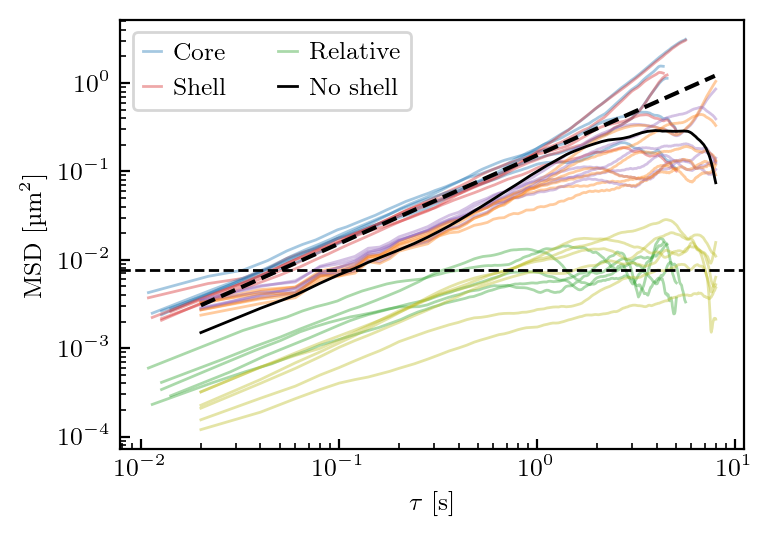

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(10/2.54, 7/2.54))

for i in range(msds1.shape[2]):
    dtimes = msds1[:,0,i]
    if i == 0:
        ax.plot(dtimes, msds1[:,8,i] * 1e12, ls='-', c='tab:blue', alpha=0.4, lw=1, label='Core')
        ax.plot(dtimes, msds1[:,7,i] * 1e12, ls='-', c='tab:red', alpha=0.4, lw=1, label='Shell')
        ax.plot(dtimes, msds1[:,9,i] * 1e12, ls='-', c='tab:green', alpha=0.4, lw=1, label='Relative')
    else:
        ax.plot(dtimes, msds1[:,8,i] * 1e12, ls='-', c='tab:blue', alpha=0.4, lw=1)
        ax.plot(dtimes, msds1[:,7,i] * 1e12, ls='-', c='tab:red', alpha=0.4, lw=1)
        ax.plot(dtimes, msds1[:,9,i] * 1e12, ls='-', c='tab:green', alpha=0.4, lw=1)

for i in range(msds2.shape[2]):
    dtimes = msds2[:,0,i]
    ax.plot(dtimes, msds2[:,8,i] * 1e12, ls='-', c='tab:purple', alpha=0.4, lw=1)
    ax.plot(dtimes, msds2[:,7,i] * 1e12, ls='-', c='tab:orange', alpha=0.4, lw=1)
    ax.plot(dtimes, msds2[:,9,i] * 1e12, ls='-', c='tab:olive', alpha=0.4, lw=1)

ax.plot(dtimes_noshell, msdnoshell * 1e12, ls='-', lw=1, c='k', label='No shell')

ax.plot(dtimes[:-2], 2 * 0.36 * (4e-21) / (6*np.pi*0.001*1e-6) * dtimes[:-2] * 1e12, ls='--', c='k')

ax.axhline(y=(2*44e-9)**2 * 1e12, ls='--', c='k', lw=1)

ax.legend(loc='upper left', ncol=2, handlelength=0.75, handletextpad=0.5)
ax.set(xlabel=r'$\tau$ [s]', ylabel=r'MSD [\textmu$\mathrm{m^2}$]', xscale='log', yscale='log')

plt.tight_layout()
plt.show()

In [52]:
# add for MSD: 
# - slope measurement for shell and core: maybe it can give a cool estimate of equivalent sphere radius for core
# - Measure slopes for the relative motion
# - Plot this slopes in a violin plot 
# - Normalize MSDs accordingly
# - Normalize MSDs with confinement (see with saturation and P(r)), to get D(available_space) or D(mean_r)
# - Plot those norm. MSDs ofc

In [53]:
def pdf(data, bins=10, density=True, range=None):
    pdf, bins_edge = np.histogram(
        data, 
        bins=bins, 
        density=density, 
        range=range, 
    )
    bins_center = (bins_edge[0:-1] + bins_edge[1:]) / 2
    return pdf, bins_center

In [54]:
datas = datas1

rs = np.sqrt((datas[:,3,:] - datas[:,1,:]) ** 2 + (datas[:,4,:] - datas[:,2,:]) ** 2)

In [55]:
nbins = 30 
binsrange = [0, 300e-9]

bins_rs, pdfs_rs = np.zeros((nbins, datas.shape[-1])), np.zeros((nbins, datas.shape[-1]))

for i in range(datas.shape[-1]):
    pdfs_rs[:,i], bins_rs[:,i] = pdf(rs[:,i], bins=nbins, range=binsrange)

In [56]:
colors = sns.color_palette('light:green', n_colors=10)[2:]

/tmp/ipykernel_21190/2642110641.py:4: RuntimeWarning: divide by zero encountered in log
  ax.plot(bins_rs[:,i]*1e9, -np.log(pdfs_rs[:,i]), ls='-', color=colors[i], label=str(i)) #marker='o', mfc=colors[i], ms=4)


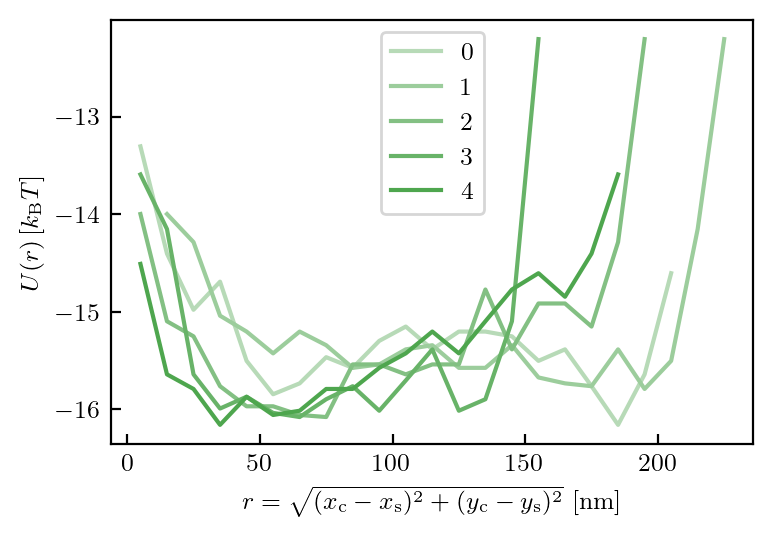

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(10/2.54, 7/2.54))

for i in range(datas.shape[-1]):
    ax.plot(bins_rs[:,i]*1e9, -np.log(pdfs_rs[:,i]), ls='-', color=colors[i], label=str(i)) #marker='o', mfc=colors[i], ms=4)
    
ax.legend()
ax.set(yscale='linear', xscale='linear', xlabel=r'$r = \sqrt{(x_\mathrm{c} - x_\mathrm{s})^2 + (y_\mathrm{c} - y_\mathrm{s})^2}$ [nm]', ylabel=r'$U(r) \, [k_\mathrm{B}T]$')

plt.tight_layout()
plt.show()

In [58]:
for i in range(datas.shape[-1]):
    print(np.min(rs[:,i])*1e9, np.max(rs[:,i])*1e9)
    print()

5.405945311809124 209.0288149433819

12.496441014041325 224.2118319187326

2.248584382375125 213.5887555416166

5.761521536212068 153.7592287439761

1.4491545825189782 181.75873993178772



In [59]:
for i, col in enumerate(columns):
    print(col, i)

time 0
xs 1
ys 2
xc 3
yc 4
Is 5
Ac 6
Ic 7


In [60]:
# itensities and area

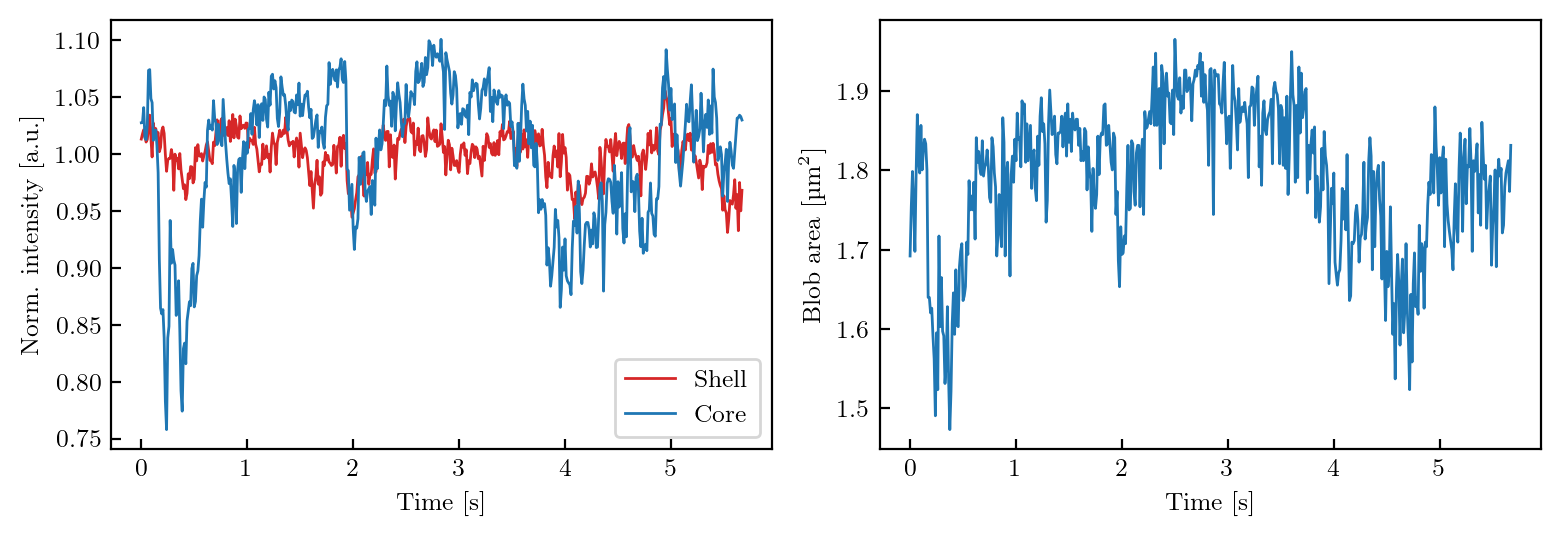

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(20/2.54, 7/2.54))

i = 4

datas = datas1

time = datas[:,0,i]
iouter = datas[:,5,i]
iinner = datas[:,7,i]
ainner = datas[:,6,i]

axes[0].plot(time, iouter / np.nanmean(iouter), ls='-', lw=1, c='tab:red', label='Shell')
axes[0].plot(time, iinner / np.nanmean(iinner), ls='-', lw=1, c='tab:blue', label='Core')

axes[1].plot(time, ainner * 1e12, ls='-', lw=1, c='tab:blue', label='Shell')

axes[0].legend()
axes[0].set(xlabel='Time [s]', ylabel=r'Norm. intensity [a.u.]', xscale='linear', yscale='linear')

axes[1].set(xlabel='Time [s]', ylabel=r'Blob area [\textmu m$^2$]', xscale='linear', yscale='linear')

plt.tight_layout()
plt.show()

In [62]:
msdiinner = moment(2, iinner, dframes, retrieve_mean=False)
msdainner = moment(2, ainner, dframes, retrieve_mean=False)

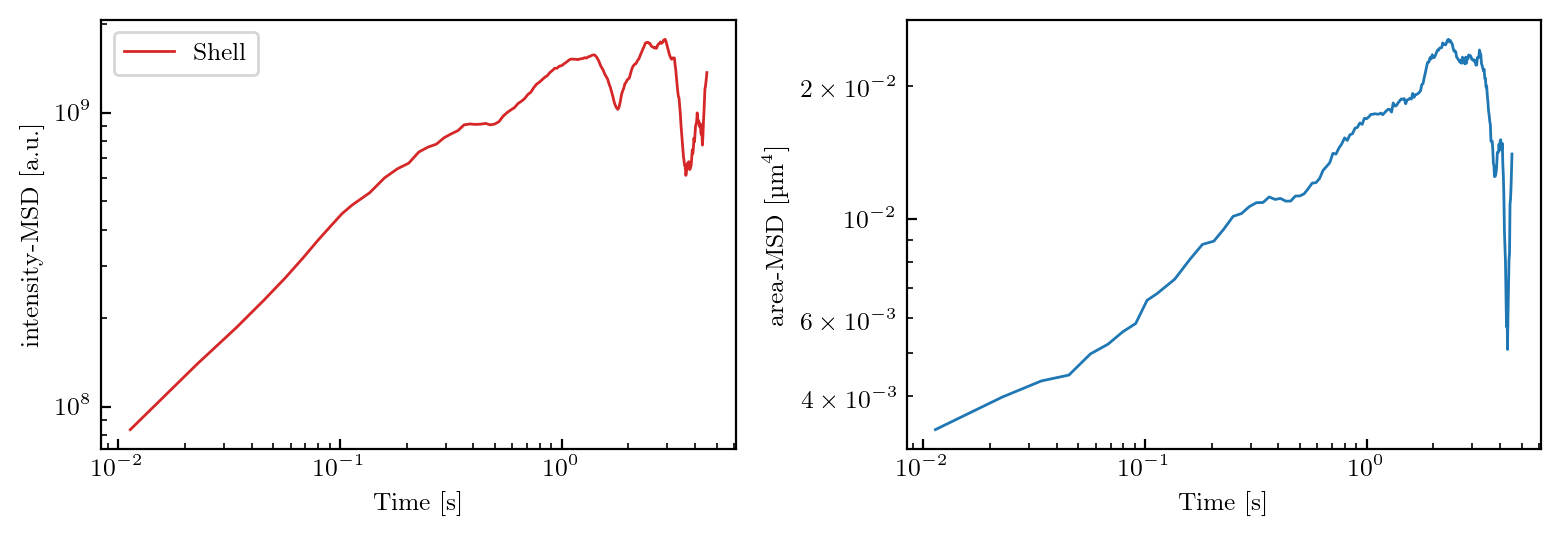

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(20/2.54, 7/2.54))

dt = np.nanmean(datas[1:,0,i] - datas[:-1,0,i])
dtimes = dframes * dt

axes[0].plot(dtimes, msdiinner, ls='-', lw=1, c='tab:red', label='Shell')

axes[1].plot(dtimes, msdainner * 1e24, ls='-', lw=1, c='tab:blue', label='Core')

axes[0].legend()
axes[0].set(xlabel='Time [s]', ylabel=r'intensity-MSD [a.u.]', xscale='log', yscale='log')

axes[1].set(xlabel='Time [s]', ylabel=r'area-MSD [\textmu m$^4$]', xscale='log', yscale='log')

plt.tight_layout()
plt.show()

In [64]:
# Correlations core-shell

In [69]:
import sys
sys.path.append('../tracking/wraptrack_coreshell/')

from correlation_functions import *

In [166]:
datas = datas2

dframes = np.arange(0, 250, 1)

nf = datas.shape[-1]

ccfs_dx = np.zeros((len(dframes), nf))
lags_dx = np.zeros((len(dframes), nf))
for i in range(nf):
    ccfs_dx[:,i] = displacement_correlation(datas[:,3,i], datas[:,1,i], dframes, kks=5)
    dt = np.nanmean(datas[1:,0,i] - datas[:-1,0,i])
    print(dt*1000)
    lags_dx[:,i] = dframes * dt

20.0
20.0
20.0
20.0
20.0
20.0


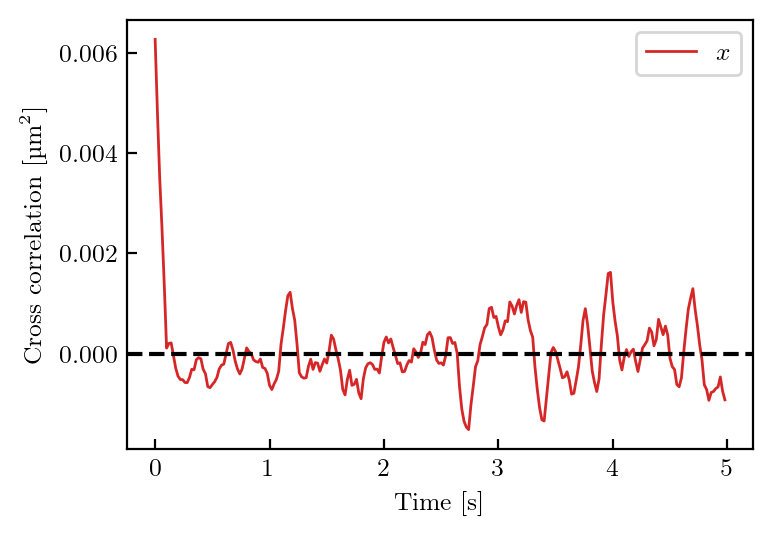

In [167]:
fig, ax = plt.subplots(1, 1, figsize=(10/2.54, 7/2.54))

i = 2

ax.plot(lags_dx[:,i], ccfs_dx[:,i] * 1e12, ls='-', lw=1, c='tab:red', label='$x$')

ax.axhline(y=0, ls='--', c='k')

ax.legend()
ax.set(xlabel='Time [s]', ylabel=r'Cross correlation [\textmu$\mathrm{m^2}$]', xscale='linear', yscale='linear')

plt.tight_layout()
plt.show()

In [174]:
for i, col in enumerate(columns):
    print(col, i)

time 0
xs 1
ys 2
xc 3
yc 4
Is 5
Ac 6
Ic 7


In [179]:
def compute_pdf(dx : np.ndarray, cutoff : float = 10, bins : int|np.ndarray = 30, normalize: bool = True):
    sample = dx[np.abs(dx) < cutoff]
    prob, bins = pdf(sample[~np.isnan(sample)], bins=bins)
    if normalize:
        prob = prob / np.trapezoid(prob, bins)
    return prob, bins
    
def datas2pdfdisplacements(datas, dtimes=0.1, nbins=30, cutoff=3):
    """
    Parameter is the time lag, not the difference of frames.
    """
    nf = datas.shape[-1]
    if type(dtimes) in [float, int]:
        dtimes = [dtimes]
    Ps = np.zeros((nbins, 2, len(dtimes), nf))
    Pc = np.zeros((nbins, 2, len(dtimes), nf))
    Pr = np.zeros((nbins, 2, len(dtimes), nf))
    for i in range(nf):
        dt = np.nanmean(datas[1:,0,i] - datas[:-1,0,i])
        dframes = [int(tt / dt) for tt in dtimes]
        for j, d in enumerate(dframes):
            dxs = datas[d:,1,i] - datas[:-d,1,i]
            dys = np.array([]) #datas[d:,2,i] - datas[:-d,2,i]
            dxys = np.concatenate((dxs, dys))
            dxc = datas[d:,3,i] - datas[:-d,3,i]
            dyc = np.array([]) #datas[d:,4,i] - datas[:-d,4,i]
            dxyc = np.concatenate((dxc, dyc))
            dr = datas[d:,8,i] - datas[:-d,8,i]
            ps, bs = compute_pdf(dxys, cutoff=cutoff*np.nanstd(dxys), bins=nbins)
            Ps[:,:,j,i] = np.array([bs, ps]).T
            pc, bc = compute_pdf(dxyc, cutoff=cutoff*np.nanstd(dxyc), bins=nbins)
            Pc[:,:,j,i] = np.array([bc, pc]).T
            pr, br = compute_pdf(dr, cutoff=cutoff*np.nanstd(dr), bins=nbins)
            Pr[:,:,j,i] = np.array([br, pr]).T
    return Ps, Pc, Pr

In [198]:
dtimes = [0.02]
Ps1, Pc1, Pr1 = datas2pdfdisplacements(datas1, dtimes=dtimes, nbins=30, cutoff=3)
Ps2, Pc2, Pr2 = datas2pdfdisplacements(datas2, dtimes=dtimes, nbins=30, cutoff=3)

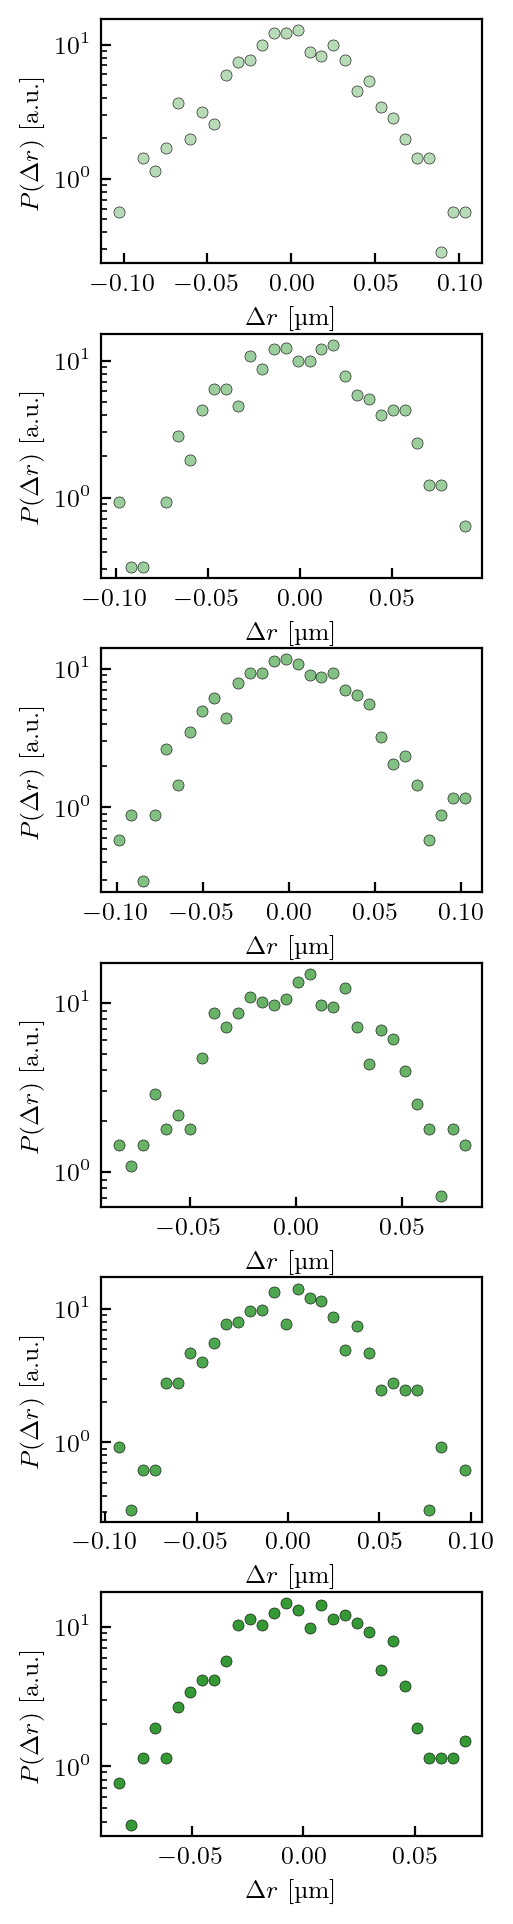

In [199]:
fig, axes = plt.subplots(nf2, 1, figsize=(6/2.54, 4*nf2/2.54))

for k in range(nf2):

    for j, d in enumerate(dtimes):

        bins, prob = Ps2[:,0,j,k], Ps2[:,1,j,k]

        axes[k].plot(bins * 1e6, prob * 1e-6, ls='', marker='o', color=colors[k], mew=0.2, ms=4)

        # if j != 0:
        #     popt, _ = curve_fit(gaussian, bins, prob, p0=[1e-6, 1e6])
        #     axes[j].plot(bins*1e6, gaussian(bins, *popt)*1e-6, ls='-', color=obs.colors_uniform[k], lw=1.5)

for j, ax in enumerate(axes[:]):
    ax.set_xlabel(r'$\Delta r$ [\textmu m]')
    ax.set_yscale('log')
    ax.set_ylabel(r'$P(\Delta r)$ [a.u.]')

plt.tight_layout(pad=0.1)
plt.show()

In [200]:
# Quick observation: 
# Shell: Gaussian, badly converged but normal.
# Orders of magnitude to be checked precisely
# Relative motion: 
# Exponential distribution at large times. Welcome back to phd.

In [ ]:
# Next
# PSD, MBR...